# 🎯 Day 046: Cross-Validation & Data Leakage Prevention

**Curriculum Phase 2:** Advanced Classical ML & Feature Engineering  
**Output File:** `046_cv_leakage_prevention.ipynb`  

---

## 📌 Learning Objectives
1. **Understand Data Leakage Types:** Distinguish between **Preprocessing Leakage** (fitting scalers/imputers on full data) and **Target Leakage** (including future/post-event signals).
2. **The WRONG vs RIGHT Way:** Quantify model performance distortion when scaling data *before* cross-validation splits versus *inside* folds.
3. **Cross-Validation Strategies:** Compare **K-Fold**, **StratifiedKFold** (for imbalanced data), and **TimeSeriesSplit** (for temporal data).
4. **Pipeline-Based Prevention:** Master Scikit-Learn `Pipeline` to strictly isolate training fold statistics from validation folds.
5. **Target Leakage Auditing:** Build a correlation audit tool to identify suspicious high-correlation features before training.

## 1. Imports & Environment Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import KFold, StratifiedKFold, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

# Setting random seeds and visual styles
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")
print("✅ All core libraries imported successfully!")

✅ All core libraries imported successfully!


## 2. Synthetic Dataset Generation
We create two datasets:
1. **Imbalanced Classification Dataset** (85% Class 0, 15% Class 1) to test StratifiedKFold.
2. **Temporal Time-Series Dataset** to demonstrate TimeSeriesSplit.

In [2]:
# 1. Imbalanced Classification Dataset
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    weights=[0.85, 0.15],
    random_state=42
)

# 2. Time-Series Synthetic Dataset
dates = pd.date_range(start="2024-01-01", periods=100, freq="D")
df_ts = pd.DataFrame({
    "date": dates,
    "feature_1": np.sin(np.linspace(0, 20, 100)) + np.random.normal(0, 0.1, 100),
    "target": np.cos(np.linspace(0, 20, 100)) + np.random.normal(0, 0.1, 100)
})

print(f"Classification Dataset Shape: X={X.shape}, Class distribution: {np.bincount(y)}")
print(f"Time-Series Dataset Shape: {df_ts.shape}")

Classification Dataset Shape: X=(1000, 20), Class distribution: [843 157]
Time-Series Dataset Shape: (100, 3)


## 3. Demonstration of Preprocessing Data Leakage

### ⚠️ What is Preprocessing Leakage?
When you scale (e.g. `StandardScaler().fit_transform(X)`) or impute your ENTIRE dataset before splitting into train/validation folds, the mean and standard deviation of the **validation fold** leak into the training features!

### 🛡️ The Solution: Scikit-Learn `Pipeline`
Using a `Pipeline` ensures that `fit_transform()` is run **ONLY** on the training fold during each CV step, and only `transform()` is applied to the validation fold.

                      Strategy  Mean Accuracy  Std Dev
            Leaky (Pre-scaled)          0.885 0.015811
Clean (Pipeline Fold-isolated)          0.885 0.015811


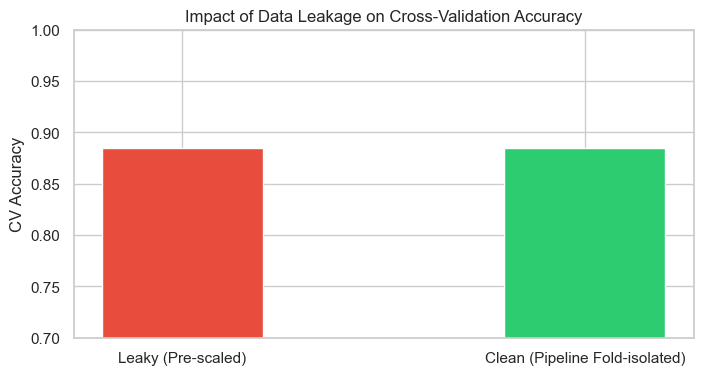

In [4]:
# --- THE WRONG WAY: Scaling BEFORE Cross-Validation Split ---
scaler_leaky = StandardScaler()
X_leaky = scaler_leaky.fit_transform(X)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model_leaky = LogisticRegression()
leaky_scores = cross_val_score(model_leaky, X_leaky, y, cv=kf, scoring='accuracy')

# --- THE RIGHT WAY: Scaling INSIDE Cross-Validation Folds via Pipeline ---
clean_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])
clean_scores = cross_val_score(clean_pipeline, X, y, cv=kf, scoring='accuracy')

# Summary Results
results_df = pd.DataFrame({
    "Strategy": ["Leaky (Pre-scaled)", "Clean (Pipeline Fold-isolated)"],
    "Mean Accuracy": [leaky_scores.mean(), clean_scores.mean()],
    "Std Dev": [leaky_scores.std(), clean_scores.std()]
})

print(results_df.to_string(index=False))

# Plot comparison
plt.figure(figsize=(8, 4))
plt.bar(results_df['Strategy'], results_df['Mean Accuracy'], color=['#e74c3c', '#2ecc71'], width=0.4)
plt.ylabel("CV Accuracy")
plt.title("Impact of Data Leakage on Cross-Validation Accuracy")
plt.ylim(0.7, 1.0)
plt.show()

## 4. Comparing Cross-Validation Strategies

In [5]:
n_splits = 5

print("--- 1. KFold vs StratifiedKFold Class Distribution ---")
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print("KFold Validation Target Ratios:", [round(y[val].mean(), 3) for _, val in kf.split(X, y)])
print("StratifiedKFold Validation Target Ratios:", [round(y[val].mean(), 3) for _, val in skf.split(X, y)])

print("\n--- 2. TimeSeriesSplit Expanding Window Indices ---")
tscv = TimeSeriesSplit(n_splits=n_splits)
for fold, (train_idx, val_idx) in enumerate(tscv.split(df_ts), 1):
    print(f"Fold {fold}: Train range [{train_idx[0]}..{train_idx[-1]}] (n={len(train_idx)}) | Val range [{val_idx[0]}..{val_idx[-1]}] (n={len(val_idx)})")

--- 1. KFold vs StratifiedKFold Class Distribution ---
KFold Validation Target Ratios: [np.float64(0.155), np.float64(0.16), np.float64(0.135), np.float64(0.175), np.float64(0.16)]
StratifiedKFold Validation Target Ratios: [np.float64(0.155), np.float64(0.155), np.float64(0.155), np.float64(0.16), np.float64(0.16)]

--- 2. TimeSeriesSplit Expanding Window Indices ---
Fold 1: Train range [0..19] (n=20) | Val range [20..35] (n=16)
Fold 2: Train range [0..35] (n=36) | Val range [36..51] (n=16)
Fold 3: Train range [0..51] (n=52) | Val range [52..67] (n=16)
Fold 4: Train range [0..67] (n=68) | Val range [68..83] (n=16)
Fold 5: Train range [0..83] (n=84) | Val range [84..99] (n=16)


## 5. Target Leakage Audit & Feature Screening

C:\Users\sahil kumar\AppData\Local\Temp\ipykernel_11932\4253823902.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.index, y=correlations.values, palette='Reds_r')


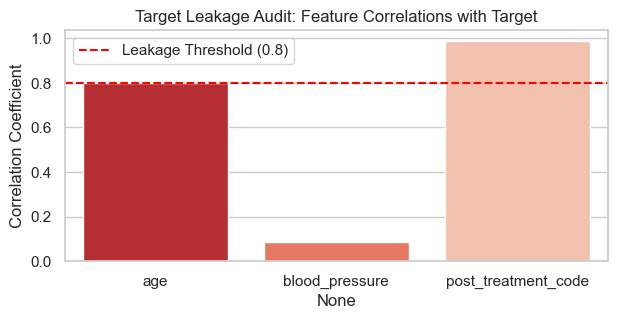

Feature 'age                 ' -> Corr: +0.7981 | Status: Clean Feature
Feature 'blood_pressure      ' -> Corr: +0.0875 | Status: Clean Feature
Feature 'post_treatment_code ' -> Corr: +0.9872 | Status: TARGET LEAKAGE DETECTED!


In [6]:
np.random.seed(42)
n = 500

age = np.random.randint(20, 80, n)
blood_pressure = np.random.normal(120, 15, n)
readmitted = (age > 60).astype(int)

# Leaky Feature: Code assigned AFTER readmission decision
post_treatment_code = readmitted * 3 + np.random.choice([0, 1], size=n, p=[0.95, 0.05])

df_audit = pd.DataFrame({
    'age': age,
    'blood_pressure': blood_pressure,
    'post_treatment_code': post_treatment_code,
    'readmitted_target': readmitted
})

correlations = df_audit.corr()['readmitted_target'].drop('readmitted_target')

plt.figure(figsize=(7, 3))
sns.barplot(x=correlations.index, y=correlations.values, palette='Reds_r')
plt.axhline(0.8, color='red', linestyle='--', label='Leakage Threshold (0.8)')
plt.title("Target Leakage Audit: Feature Correlations with Target")
plt.ylabel("Correlation Coefficient")
plt.legend()
plt.show()

for feat, corr in correlations.items():
    status = "TARGET LEAKAGE DETECTED!" if abs(corr) > 0.8 else "Clean Feature"
    print(f"Feature '{feat:20s}' -> Corr: {corr:+.4f} | Status: {status}")

## 6. Summary Checklist for Leakage Prevention

1. Always use `sklearn.pipeline.Pipeline` for chaining preprocessors and estimators.
2. Never fit preprocessing transformers on the whole dataset before train/validation split.
3. Use `StratifiedKFold` for imbalanced classification tasks to maintain target distribution.
4. Use `TimeSeriesSplit` for temporal datasets to prevent future-to-past time leakage.
5. Conduct correlation and feature-origin audits to drop post-event target-leaking features.

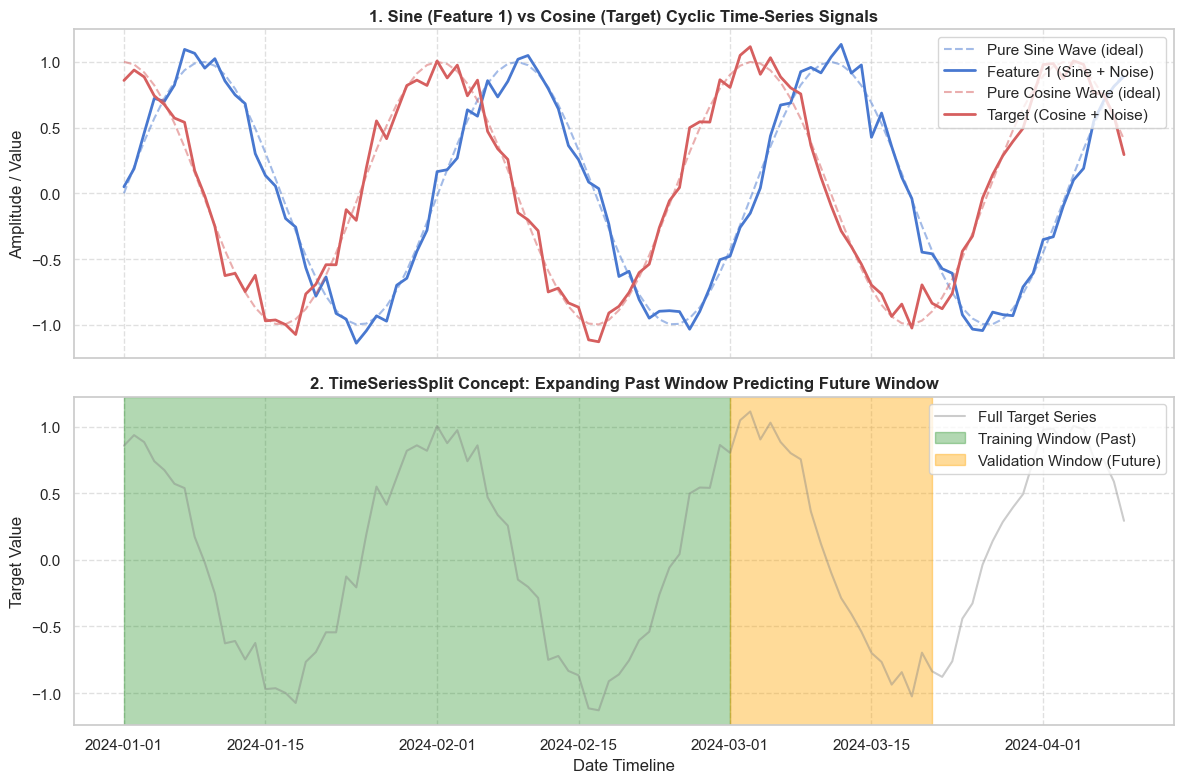

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sine & Cosine Time-Series Synthetic Dataset Create Karein
dates = pd.date_range(start="2024-01-01", periods=100, freq="D")
x = np.linspace(0, 20, 100)

# Pure mathematical waves
sin_pure = np.sin(x)
cos_pure = np.cos(x)

# Waves + Noise (Actual dataset in notebook)
np.random.seed(42)
feature_1_noisy = sin_pure + np.random.normal(0, 0.1, 100)
target_noisy = cos_pure + np.random.normal(0, 0.1, 100)

# DataFrame Setup
df_ts = pd.DataFrame({
    "date": dates,
    "feature_1": feature_1_noisy,
    "target": target_noisy
})

# 2. Visualizations Plotting (Subplots)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Subplot 1: Ideal Waves vs Noisy Real-world Data
axes[0].plot(df_ts["date"], sin_pure, 'b--', alpha=0.5, label="Pure Sine Wave (ideal)")
axes[0].plot(df_ts["date"], df_ts["feature_1"], 'b-', linewidth=2, label="Feature 1 (Sine + Noise)")
axes[0].plot(df_ts["date"], cos_pure, 'r--', alpha=0.5, label="Pure Cosine Wave (ideal)")
axes[0].plot(df_ts["date"], df_ts["target"], 'r-', linewidth=2, label="Target (Cosine + Noise)")
axes[0].set_title("1. Sine (Feature 1) vs Cosine (Target) Cyclic Time-Series Signals", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Amplitude / Value")
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Subplot 2: TimeSeriesSplit Expanding Window Visualization
axes[1].plot(df_ts["date"], df_ts["target"], color="gray", alpha=0.4, label="Full Target Series")
# Highlight Train vs Validation Split Example (e.g., Fold 3)
split_point = 60
val_end = 80
axes[1].axvspan(df_ts["date"].iloc[0], df_ts["date"].iloc[split_point], color="green", alpha=0.3, label="Training Window (Past)")
axes[1].axvspan(df_ts["date"].iloc[split_point], df_ts["date"].iloc[val_end], color="orange", alpha=0.4, label="Validation Window (Future)")

axes[1].set_title("2. TimeSeriesSplit Concept: Expanding Past Window Predicting Future Window", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Date Timeline")
axes[1].set_ylabel("Target Value")
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()